### Import Libraries


In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

### Connect PostgreSQL

In [2]:
load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("✓ Connected Successfully")

✓ Connected Successfully


### Load Dataset

In [3]:
df = pd.read_sql(
    "SELECT * FROM customers_features",
    engine
)

print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

print(df.shape)
df.head()

LOGISTIC REGRESSION
(7043, 26)


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,paperless_billing,payment_method,monthly_charges,total_charges,churn,charge_per_tenure,service_count,charge_to_value_ratio,support_dependency_score,tenure_contract_risk
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,Yes,Electronic check,29.85,29.85,No,14.925000,1,14.9250,1,0.986111
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,53.985714,3,14.2375,2,0.263889
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,36.050000,3,13.4625,2,0.972222
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,3,10.5750,3,0.187500
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,50.550000,1,35.3500,0,0.972222


### Verify Engineered Features


In [4]:
ENGINEERED = [
    "charge_per_tenure",
    "service_count",
    "charge_to_value_ratio",
    "support_dependency_score",
    "tenure_contract_risk"
]

print("Checking engineered features...")

missing = [col for col in ENGINEERED if col not in df.columns]

if len(missing)==0:
    print("✓ All engineered features found")
else:
    print("Missing Features :",missing)

Checking engineered features...
✓ All engineered features found


### Data Preparation

In [5]:
df["total_charges"] = pd.to_numeric(
    df["total_charges"],
    errors="coerce"
).fillna(0)

df["churn_binary"] = (
    df["churn"]=="Yes"
).astype(int)

### Encode Categorical Variables

In [6]:
NUMERIC = [
    "tenure",
    "monthly_charges",
    "total_charges",
    "senior_citizen"
]

df["contract_enc"] = df["contract"].map(
    {
        "Month-to-month":0,
        "One year":1,
        "Two year":2
    }
)

df["gender_enc"] = (
    df["gender"]=="Male"
).astype(int)

df["partner_enc"] = (
    df["partner"]=="Yes"
).astype(int)

df["dependents_enc"] = (
    df["dependents"]=="Yes"
).astype(int)

df["paperless_enc"] = (
    df["paperless_billing"]=="Yes"
).astype(int)

df = pd.get_dummies(
    df,
    columns=["internet_service","payment_method"],
    prefix=["internet","payment"],
    drop_first=False
)

### Prepare Features


In [7]:
ALL_FEATURES = (
    ENGINEERED +
    NUMERIC +
    [
        "contract_enc",
        "gender_enc",
        "partner_enc",
        "dependents_enc",
        "paperless_enc"
    ] +
    [c for c in df.columns if c.startswith("internet_")] +
    [c for c in df.columns if c.startswith("payment_")]
)

X = df[ALL_FEATURES]

y = df["churn_binary"]

print(X.shape)

(7043, 21)


### Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Train :",X_train.shape)
print("Test  :",X_test.shape)

Train : (5634, 21)
Test  : (1409, 21)


### Standard Scaling


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("✓ Scaling Completed")

✓ Scaling Completed


### Train Logistic Regression

In [10]:
lr = LogisticRegression(

    C=1.0,

    max_iter=1000,

    class_weight="balanced",

    random_state=42,

    solver="lbfgs"

)

lr.fit(
    X_train_scaled,
    y_train
)

print("✓ Logistic Regression Trained")

✓ Logistic Regression Trained


### Prediction


In [11]:
y_pred = lr.predict(
    X_test_scaled
)

y_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

### Model Evaluation


In [12]:
accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

roc = roc_auc_score(y_test,y_prob)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc:.4f}")

MODEL PERFORMANCE
Accuracy  : 0.7424
Precision : 0.5094
Recall    : 0.7995
F1 Score  : 0.6223
ROC AUC   : 0.8461


### Confusion Matrix

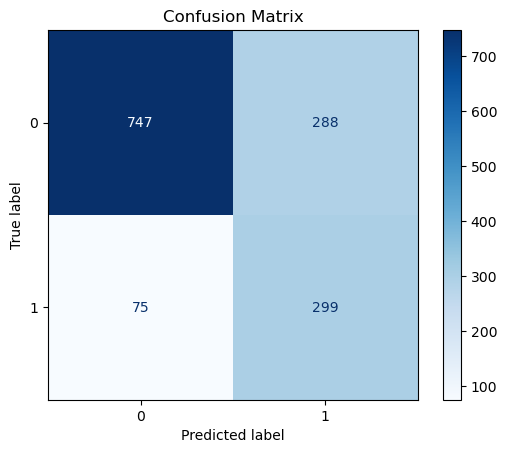

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

### Classification Report

In [14]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



### ROC Curve

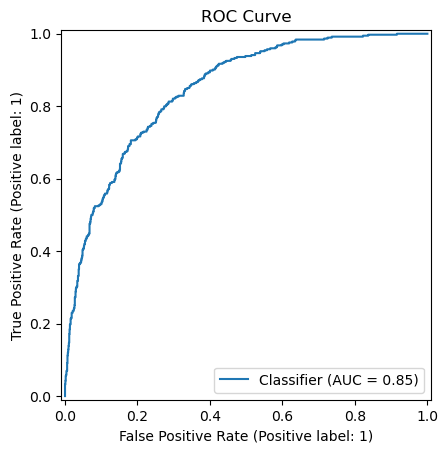

In [15]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "ROC Curve"
)

plt.show()

### Feature Importance (Coefficients)

In [16]:
coef = pd.DataFrame({

    "Feature":ALL_FEATURES,

    "Coefficient":lr.coef_[0]

})

coef = coef.sort_values(
    "Coefficient",
    ascending=False
)

coef.head(15)

,Feature,Coefficient
1,service_count,1.323487
15,internet_Fiber optic,0.939499
4,tenure_contract_risk,0.542967
7,total_charges,0.475051
13,paperless_enc,0.173748
19,payment_Electronic check,0.133421
8,senior_citizen,0.045467
11,partner_enc,0.041107
10,gender_enc,0.021732
20,payment_Mailed check,-0.044874


### Save Model

In [17]:
os.makedirs(
    "saved_models",
    exist_ok=True
)

joblib.dump(
    lr,
    "saved_models/logistic_regression.pkl"
)

joblib.dump(
    scaler,
    "saved_models/scaler.pkl"
)

print("✓ Model Saved")

✓ Model Saved


### Final Report

In [18]:
print("=" * 60)
print("LOGISTIC REGRESSION REPORT")
print("=" * 60)

print(f"Dataset Rows            : {len(df)}")
print(f"Total Features          : {X.shape[1]}")
print(f"Training Samples        : {len(X_train)}")
print(f"Testing Samples         : {len(X_test)}")

print("\nModel Performance")
print("-" * 40)

print(f"Accuracy               : {accuracy:.4f}")
print(f"Precision              : {precision:.4f}")
print(f"Recall                 : {recall:.4f}")
print(f"F1 Score               : {f1:.4f}")
print(f"ROC-AUC                : {roc:.4f}")

print("\nConfusion Matrix Summary")
print("-" * 40)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"True Positives         : {tp}")
print(f"True Negatives         : {tn}")
print(f"False Positives        : {fp}")
print(f"False Negatives        : {fn}")

print("\nTop Positive Predictors")
print("-" * 40)

top_positive = coef.sort_values("Coefficient", ascending=False).head(5)

for _, row in top_positive.iterrows():
    print(f"{row['Feature']:30s} : {row['Coefficient']:.4f}")

print("\nBusiness Findings")
print("-" * 40)
print("• Logistic Regression was successfully trained using engineered and customer profile features.")
print("• Class imbalance was handled using class_weight='balanced', improving churn detection.")
print(f"• The model achieved an ROC-AUC of {roc:.2f}, indicating good discrimination between churn and non-churn customers.")
print(f"• Recall of {recall:.2f} shows the model successfully identified approximately {recall*100:.1f}% of actual churners.")
print(f"• Precision of {precision:.2f} indicates that approximately {precision*100:.1f}% of predicted churners were actual churners.")
print("• Feature importance analysis identified 'service_count', 'internet_Fiber optic', and 'tenure_contract_risk' as the strongest positive predictors of churn.")
print("• This Logistic Regression model provides an interpretable baseline and will be compared with Random Forest and XGBoost in the next phase.")

print("\nModel Artifacts")
print("-" * 40)
print("✓ logistic_regression.pkl saved")
print("✓ scaler.pkl saved")

print("\n✓ Logistic Regression Pipeline Completed Successfully.")

LOGISTIC REGRESSION REPORT
Dataset Rows            : 7043
Total Features          : 21
Training Samples        : 5634
Testing Samples         : 1409

Model Performance
----------------------------------------
Accuracy               : 0.7424
Precision              : 0.5094
Recall                 : 0.7995
F1 Score               : 0.6223
ROC-AUC                : 0.8461

Confusion Matrix Summary
----------------------------------------
True Positives         : 299
True Negatives         : 747
False Positives        : 288
False Negatives        : 75

Top Positive Predictors
----------------------------------------
service_count                  : 1.3235
internet_Fiber optic           : 0.9395
tenure_contract_risk           : 0.5430
total_charges                  : 0.4751
paperless_enc                  : 0.1737

Business Findings
----------------------------------------
• Logistic Regression was successfully trained using engineered and customer profile features.
• Class imbalance was handle